In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Bibliothèques importées avec succès")

 Bibliothèques importées avec succès


In [2]:
df = pd.read_csv('../data/raw/dataset_ProjetML_2026.csv')

In [3]:
print(f"Shape : {df.shape}")

Shape : (10500, 9)


In [5]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [6]:
print("=== INFORMATIONS GENERALES ===")
print(df.info())

=== INFORMATIONS GENERALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB
None


In [7]:
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== STATISTIQUES DESCRIPTIVES ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [8]:
print("Doublons :", df.duplicated().sum())

Doublons : 776


In [9]:
df = df.drop_duplicates()

In [10]:
print("Après suppression :", df.shape)


Après suppression : (9724, 9)


In [11]:
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_df)

=== VALEURS MANQUANTES ===
                  Manquants  Pourcentage (%)
Poids                   974            10.02
Volume                  537             5.52
Conductivite            972            10.00
Opacite                 989            10.17
Rigidite                554             5.70
Prix_Revente            533             5.48
Categorie               511             5.26
Source                  535             5.50
Rapport_Collecte          0             0.00


=== DISTRIBUTION DE LA CIBLE ===
Categorie
Plastique    2562
Verre        2384
Métal        2163
Papier       2104
NaN           511
Name: count, dtype: int64


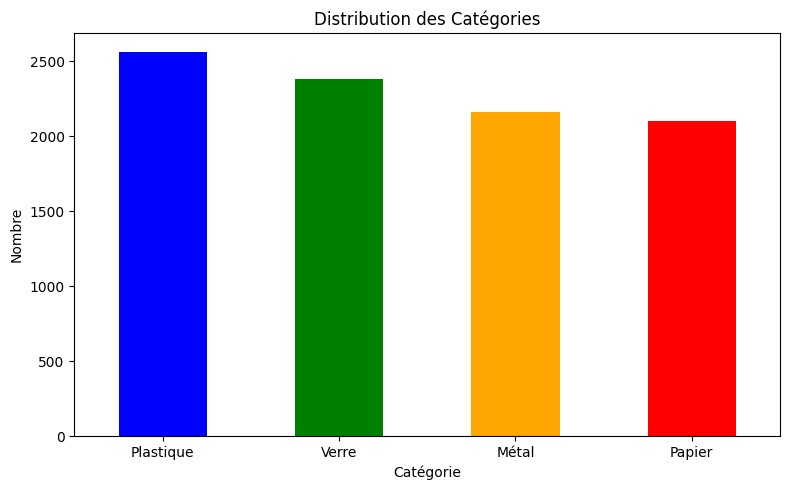

In [12]:
print("=== DISTRIBUTION DE LA CIBLE ===")
print(df['Categorie'].value_counts(dropna=False))

plt.figure(figsize=(8,5))
df['Categorie'].value_counts().plot(kind='bar', color=['blue','green','orange','red'])
plt.title('Distribution des Catégories')
plt.xlabel('Catégorie')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

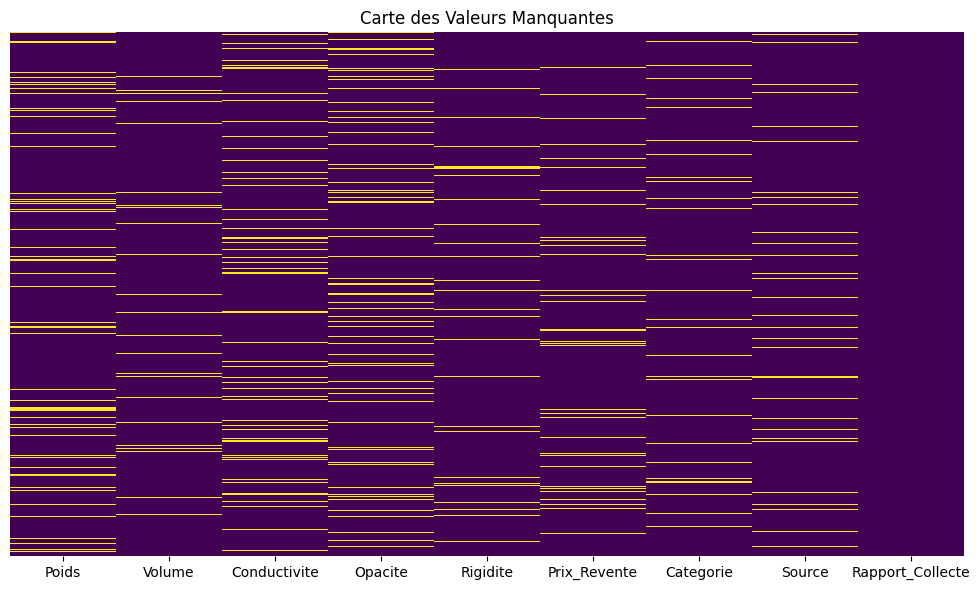

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Carte des Valeurs Manquantes')
plt.tight_layout()
plt.show()

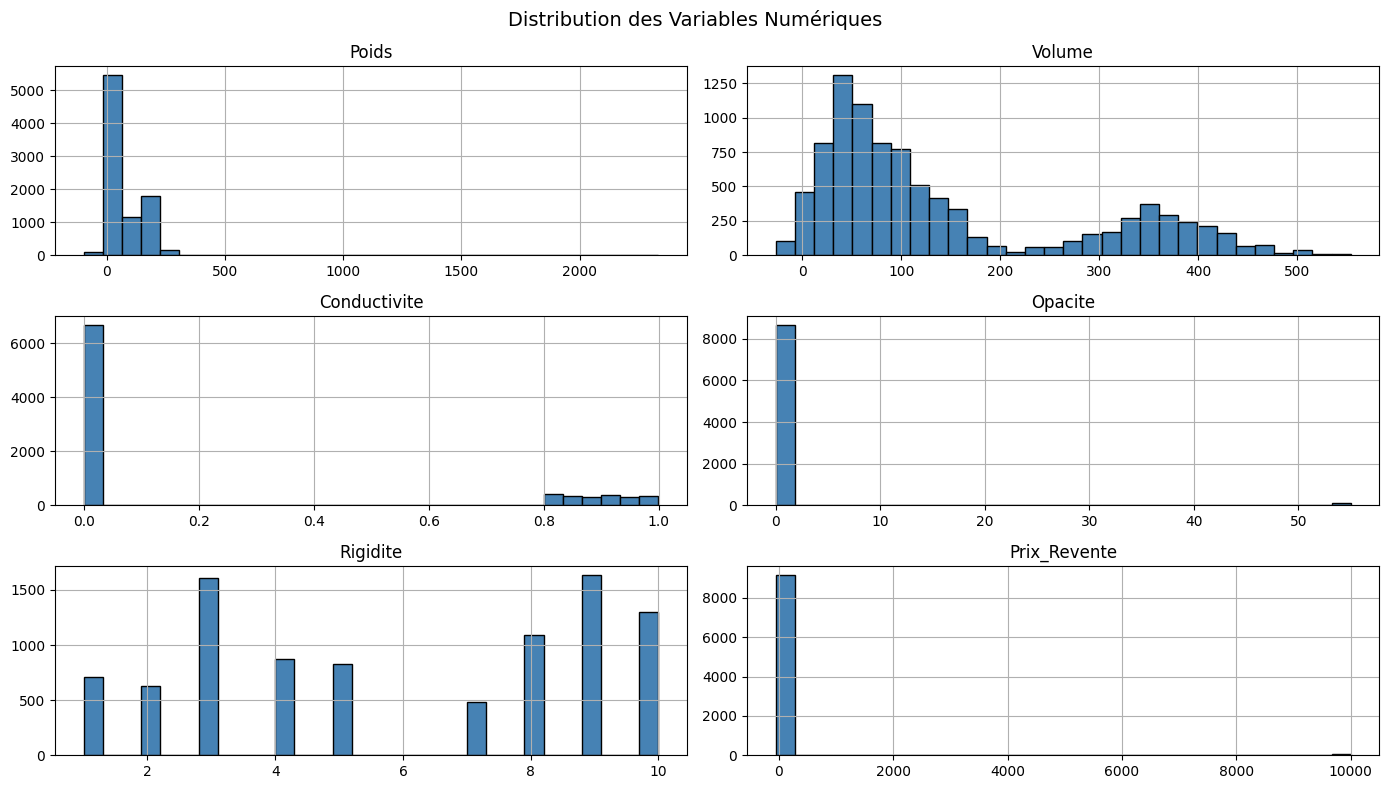

In [14]:
cols_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

df[cols_numeriques].hist(figsize=(14,8), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution des Variables Numériques', fontsize=14)
plt.tight_layout()
plt.show()

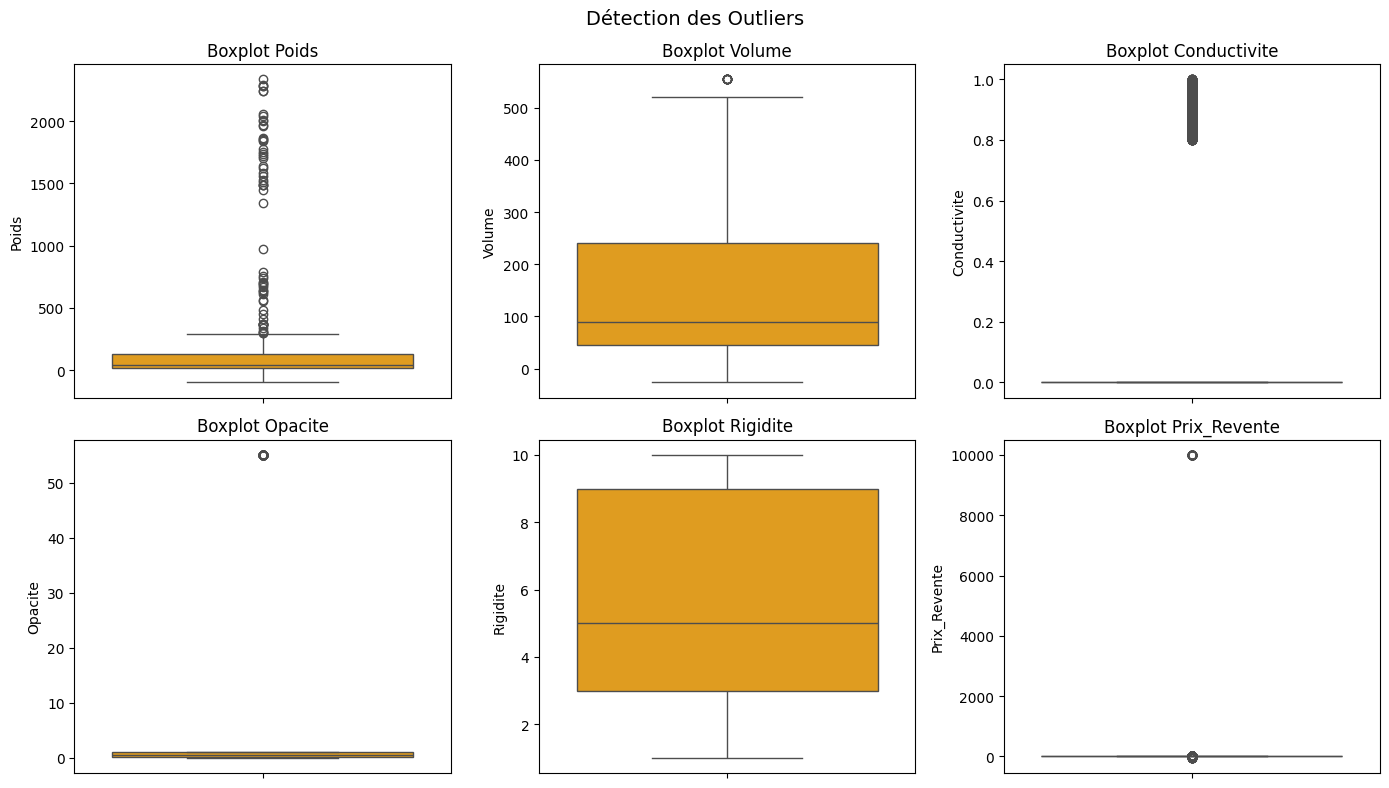

In [15]:
plt.figure(figsize=(14,8))
for i, col in enumerate(cols_numeriques):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='orange')
    plt.title(f'Boxplot {col}')
plt.suptitle('Détection des Outliers', fontsize=14)
plt.tight_layout()
plt.show()

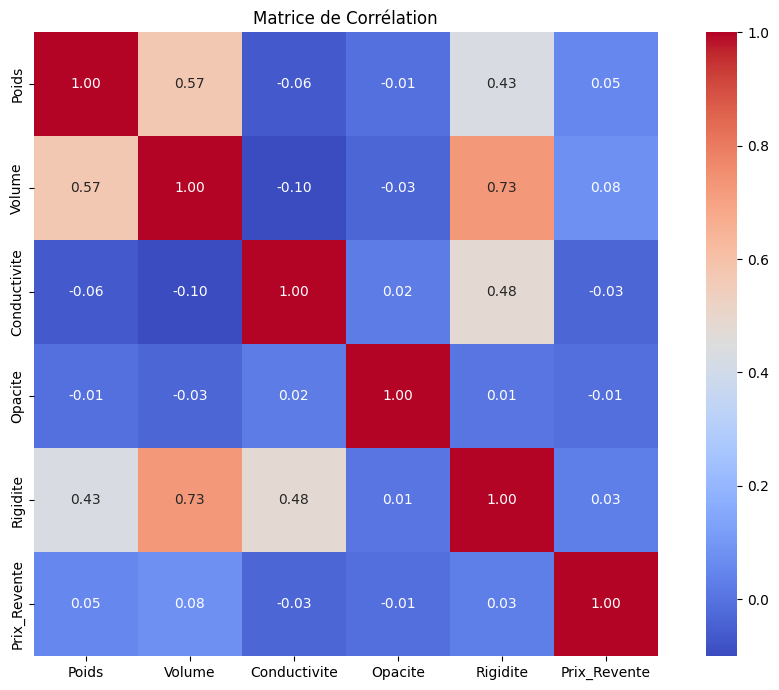

In [16]:
plt.figure(figsize=(10,7))
corr = df[cols_numeriques].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

In [17]:
print("=== AVANT NETTOYAGE ===")
print(f"Lignes : {len(df)}")
print(f"Poids min : {df['Poids'].min()}")
print(f"Volume min : {df['Volume'].min()}")
print(f"Prix_Revente max : {df['Prix_Revente'].max()}")

# Supprimer valeurs impossibles
df = df[df['Poids'] > 0]        # Poids négatif impossible
df = df[df['Volume'] > 0]       # Volume négatif impossible
df = df[df['Prix_Revente'] >= 0] # Prix négatif impossible

print("\n=== APRES NETTOYAGE BASIQUE ===")
print(f"Lignes restantes : {len(df)}")

=== AVANT NETTOYAGE ===
Lignes : 9724
Poids min : -99.0
Volume min : -26.80771241307457
Prix_Revente max : 9999.0

=== APRES NETTOYAGE BASIQUE ===
Lignes restantes : 7527


In [18]:
def supprimer_outliers_iqr(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 3 * IQR
    borne_sup = Q3 + 3 * IQR
    avant = len(df)
    df = df[(df[colonne] >= borne_inf) & (df[colonne] <= borne_sup)]
    print(f"{colonne} : {avant - len(df)} outliers supprimés")
    return df

for col in ['Poids', 'Volume', 'Prix_Revente']:
    df = supprimer_outliers_iqr(df, col)

print(f"\nLignes finales : {len(df)}")

Poids : 43 outliers supprimés
Volume : 0 outliers supprimés
Prix_Revente : 310 outliers supprimés

Lignes finales : 7174


In [19]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

print("=== VALEURS MANQUANTES AVANT IMPUTATION ===")
print(df[cols_numeriques].isnull().sum())

=== VALEURS MANQUANTES AVANT IMPUTATION ===
Poids             0
Volume            0
Conductivite    723
Opacite         728
Rigidite        404
Prix_Revente      0
dtype: int64


In [20]:
# Copie du dataframe pour chaque stratégie
df_mediane = df.copy()
df_knn = df.copy()
df_iterative = df.copy()

# Stratégie 1 : Médiane
imputer_mediane = SimpleImputer(strategy='median')
df_mediane[cols_numeriques] = imputer_mediane.fit_transform(df[cols_numeriques])

# Stratégie 2 : KNN
imputer_knn = KNNImputer(n_neighbors=5)
df_knn[cols_numeriques] = imputer_knn.fit_transform(df[cols_numeriques])

# Stratégie 3 : Iterative
imputer_iterative = IterativeImputer(random_state=42)
df_iterative[cols_numeriques] = imputer_iterative.fit_transform(df[cols_numeriques])

print(" 3 stratégies d'imputation appliquées")
print(f"Valeurs manquantes après médiane : {df_mediane[cols_numeriques].isnull().sum().sum()}")
print(f"Valeurs manquantes après KNN     : {df_knn[cols_numeriques].isnull().sum().sum()}")
print(f"Valeurs manquantes après itératif: {df_iterative[cols_numeriques].isnull().sum().sum()}")

 3 stratégies d'imputation appliquées
Valeurs manquantes après médiane : 0
Valeurs manquantes après KNN     : 0
Valeurs manquantes après itératif: 0


In [21]:
# On garde KNN (meilleure pour données corrélées)
df_clean = df_knn.copy()

# Vérification finale
print("=== DATASET FINAL ===")
print(f"Shape : {df_clean.shape}")
print(f"Valeurs manquantes : {df_clean.isnull().sum().sum()}")

=== DATASET FINAL ===
Shape : (7174, 9)
Valeurs manquantes : 782


In [22]:
print("=== VALEURS MANQUANTES PAR COLONNE ===")
print(df_clean.isnull().sum())

# Source : imputer avec le mode (valeur la plus fréquente)
df_clean['Source'].fillna(df_clean['Source'].mode()[0], inplace=True)

# Categorie : on garde les NaN pour l'instant (semi-supervisé plus tard)
print("\n=== APRES TRAITEMENT SOURCE ===")
print(df_clean.isnull().sum())
print(f"\nValeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

=== VALEURS MANQUANTES PAR COLONNE ===
Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           383
Source              399
Rapport_Collecte      0
dtype: int64

=== APRES TRAITEMENT SOURCE ===
Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           383
Source                0
Rapport_Collecte      0
dtype: int64

Valeurs manquantes restantes : 383


In [23]:
from sklearn.preprocessing import LabelEncoder

# Encoder Source
le_source = LabelEncoder()
df_clean['Source_encoded'] = le_source.fit_transform(df_clean['Source'])

# Encoder Categorie (seulement les lignes non-NaN)
le_categorie = LabelEncoder()
mask = df_clean['Categorie'].notna()
df_clean.loc[mask, 'Categorie_encoded'] = le_categorie.fit_transform(df_clean.loc[mask, 'Categorie'])

print("=== ENCODAGE ===")
print("Source :", le_source.classes_)
print("Categorie :", le_categorie.classes_)
print(df_clean[['Source', 'Source_encoded', 'Categorie', 'Categorie_encoded']].head(8))

=== ENCODAGE ===
Source : ['Centre_Tri' 'Collecte_Citoyenne' 'Usine_A' 'Usine_B']
Categorie : ['Métal' 'Papier' 'Plastique' 'Verre']
                Source  Source_encoded  Categorie  Categorie_encoded
0   Collecte_Citoyenne               1     Papier                1.0
1              Usine_A               2  Plastique                2.0
5              Usine_B               3  Plastique                2.0
6   Collecte_Citoyenne               1      Verre                3.0
7   Collecte_Citoyenne               1      Verre                3.0
8              Usine_A               2     Papier                1.0
9           Centre_Tri               0      Métal                0.0
10  Collecte_Citoyenne               1     Papier                1.0


In [24]:
from sklearn.preprocessing import StandardScaler

cols_a_normaliser = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']

scaler = StandardScaler()
df_clean[cols_a_normaliser] = scaler.fit_transform(df_clean[cols_a_normaliser])

print("=== APRES NORMALISATION ===")
print(df_clean[cols_a_normaliser].describe().round(2))

=== APRES NORMALISATION ===
         Poids   Volume  Conductivite  Opacite  Rigidite
count  7174.00  7174.00       7174.00  7174.00   7174.00
mean     -0.00     0.00         -0.00     0.00      0.00
std       1.00     1.00          1.00     1.00      1.00
min      -1.02    -1.07         -0.52    -0.21     -1.58
25%      -0.76    -0.74         -0.52    -0.18     -0.94
50%      -0.49    -0.44         -0.52    -0.11     -0.29
75%       0.97     0.91         -0.52    -0.03      1.00
max       5.37     2.95          2.21     9.58      1.33


In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_csv('../data/processed/dataset_clean.csv', index=False)
print("Dataset nettoyé sauvegardé !")
print(f"Shape final : {df_clean.shape}")